## Notebook 7

This notebook illustrates the training and prediction of a Neural Ordinary Differential Equation (NODEs) model.  The data is fictitiously generated by solving the Lotka-Volterra model

$\frac{dx}{dt}=\alpha x -\beta xy$

$\frac{dy}{dt}=-\gamma y +\delta xy$

with initial condition $x(0)=1$ and $y(0)=1$.   In this notebook, we will use $\alpha=1.5$, $\beta=1.0$, $\gamma=3.0$ $\delta=1.0$. Training data is generated for $t\in[0,20]$. The intention is to try to use the NODEs model to predict the solution for $t\in[0,50]$.    

The NODEs model look like


$\frac{d\vec{u}}{dt}=\vec{NN}(\vec{u};\vec{p})$


The Neural Network has two inputs, $u_1$ and $u_2$ and two outputs $du_1/dt$ and $du_2/dt$.  

In [4]:
using ComponentArrays
using Lux
using DiffEqFlux 
using OrdinaryDiffEq
using SciMLSensitivity
using Optimization
using OptimizationOptimisers
using Random
using CairoMakie
using MLUtils
using OrdinaryDiffEqTsit5

Parameters for Training Data

In [5]:
rng = Xoshiro(0)
u0 = Float32[1.0;1.0]
datasize = 500
tspan = (0.0f0, 20.0f0)
tsteps = range(tspan[1], tspan[2]; length = datasize)

EpanechnikovKernelBandwidth=0.02
noise=0.1

0.1

Parameters for Validation Data

In [6]:
tspan2 = (0.0f0, 50.0f0)
tsteps2 = range(tspan2[1], tspan2[2]; length = 500)

0.0f0:0.1002004f0:50.0f0

Training parameters

In [7]:
max_iter_colloc=2000
max_iter_NODEs=2000
learning_rate=0.01

0.01

Lotka Volterra equation


$\frac{du_1}{dt}=1.5 u_1 -u_1 u_2$

$\frac{du_2}{dt}=-3 u_2 +u_1u_2$

In [8]:
function trueODEfunc(du, u, p, t)
    du[1]=1.5*u[1]-u[1]*u[2]
    du[2]=-3*u[2]+u[1]*u[2]
end

trueODEfunc (generic function with 1 method)

Generating training data

In [9]:
prob_trueode = ODEProblem(trueODEfunc, u0, tspan)
data = Array(solve(prob_trueode, Tsit5(); saveat = tsteps)) .+ noise*randn(length(u0), datasize)

2×500 Matrix{Float64}:
 1.08131   0.887131  0.954433  1.27483   …  1.01848   0.988885  1.148
 0.983209  0.883642  0.808189  0.811542     0.905863  0.867216  0.793302

Generating Validation data

In [10]:
prob_trueode_sol = ODEProblem(trueODEfunc, u0, tspan2)
data_true = Array(solve(prob_trueode_sol, Tsit5(); saveat = tsteps2)) 

2×500 Matrix{Float32}:
 1.0  1.06122   1.1444    1.24987   1.37877   …  1.24666   1.36633   1.5108
 1.0  0.820765  0.678548  0.566297  0.478191     0.637206  0.537629  0.459627

Plot to see how the training and validation data looks like

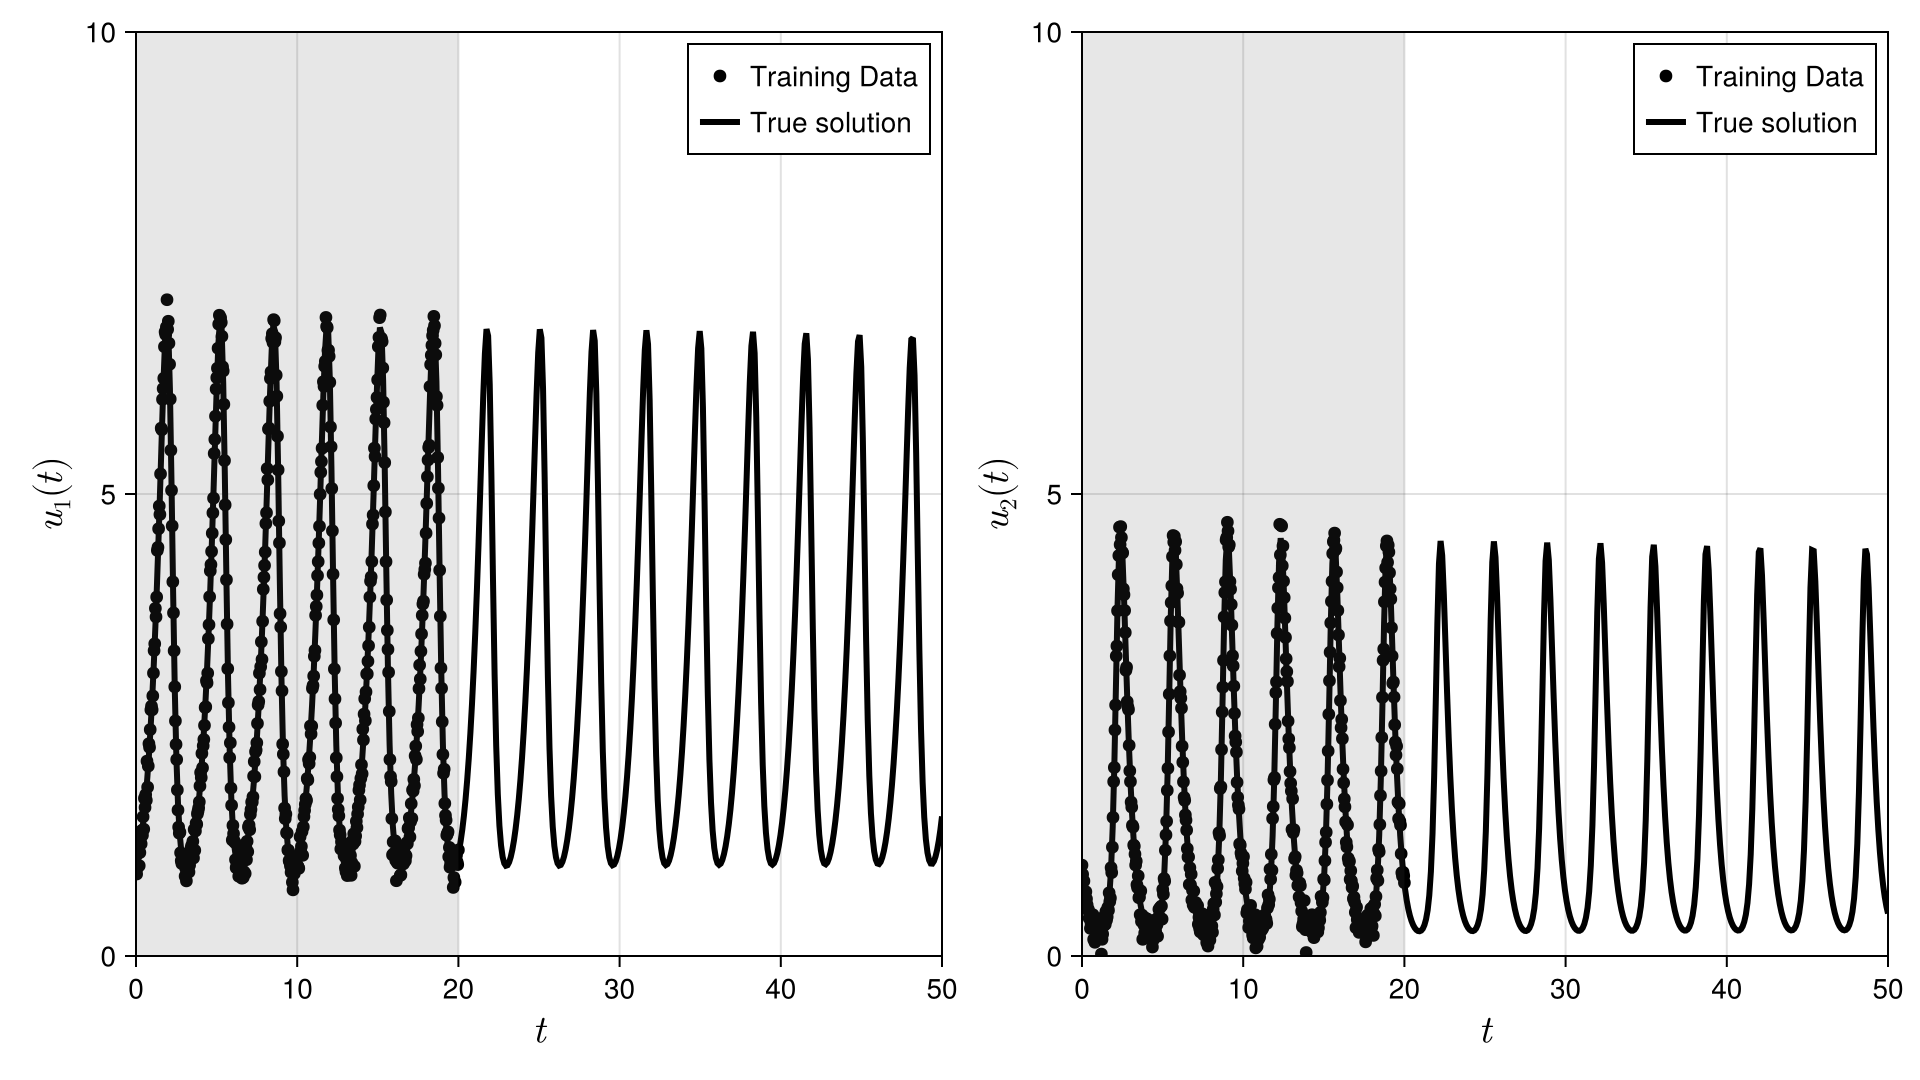

In [13]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)",title="")
CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Training Data")
CairoMakie.lines!(ax1,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.vspan!(ax1,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax1;position=:rt)
xlims!(ax1,tspan2[1],tspan2[2])
ylims!(ax1,0,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)",title="")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black,label="Training Data")
CairoMakie.lines!(ax2,tsteps2, data_true[2,:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.vspan!(ax2,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax2;position=:rt)
xlims!(ax2,tspan2[1],tspan2[2])
ylims!(ax2,0,10)

fig

Using the inbuilt `collocate_data()` function to smooth the data and approximate the time derivative of the data

In [14]:
du, u = collocate_data(data, tsteps, EpanechnikovKernel(),EpanechnikovKernelBandwidth)

([0.2931327976299105 0.39510155670499625 … 0.9114591746092728 0.6370764247488263; -1.9694555551333137 -1.717261651183272 … -1.2922131409789914 -0.24569412248590883], [0.9887982072492891 1.0137432513025626 … 1.0666097404535635 1.1001232501123857; 0.9393465243392886 0.8848094645035882 … 0.8001711161138958 0.7085147622722355])

Plot the smoothed data to check if it looks reasonable

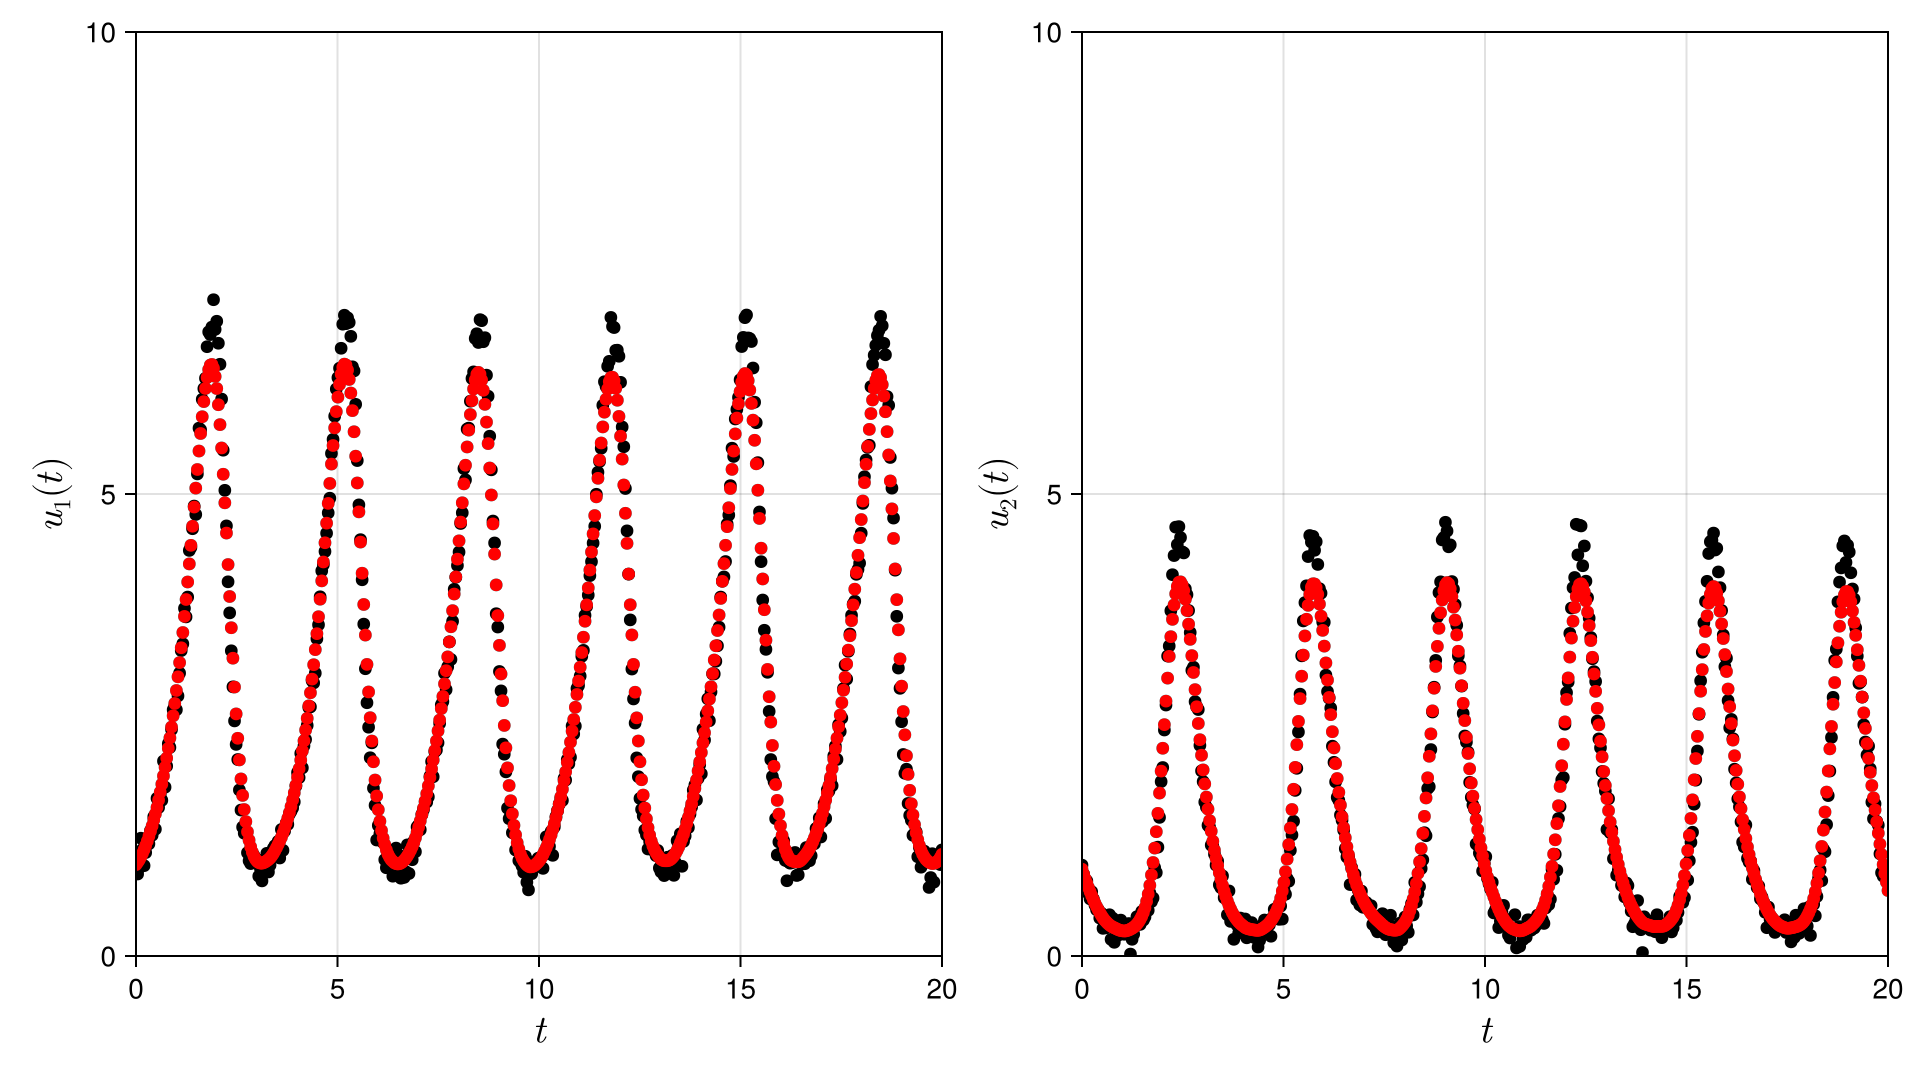

In [15]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)")
CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black)
CairoMakie.scatter!(ax1,tsteps, u[1,:];color=:red)
xlims!(ax1,0,tspan[2])
ylims!(ax1,0,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black)
CairoMakie.scatter!(ax2,tsteps, u[2,:]; color=:red)
xlims!(ax2,0,tspan[2])
ylims!(ax2,0,10)
save("colloc.png", fig)
fig

Plot the approximated derivative of the data to check if it looks reasonable

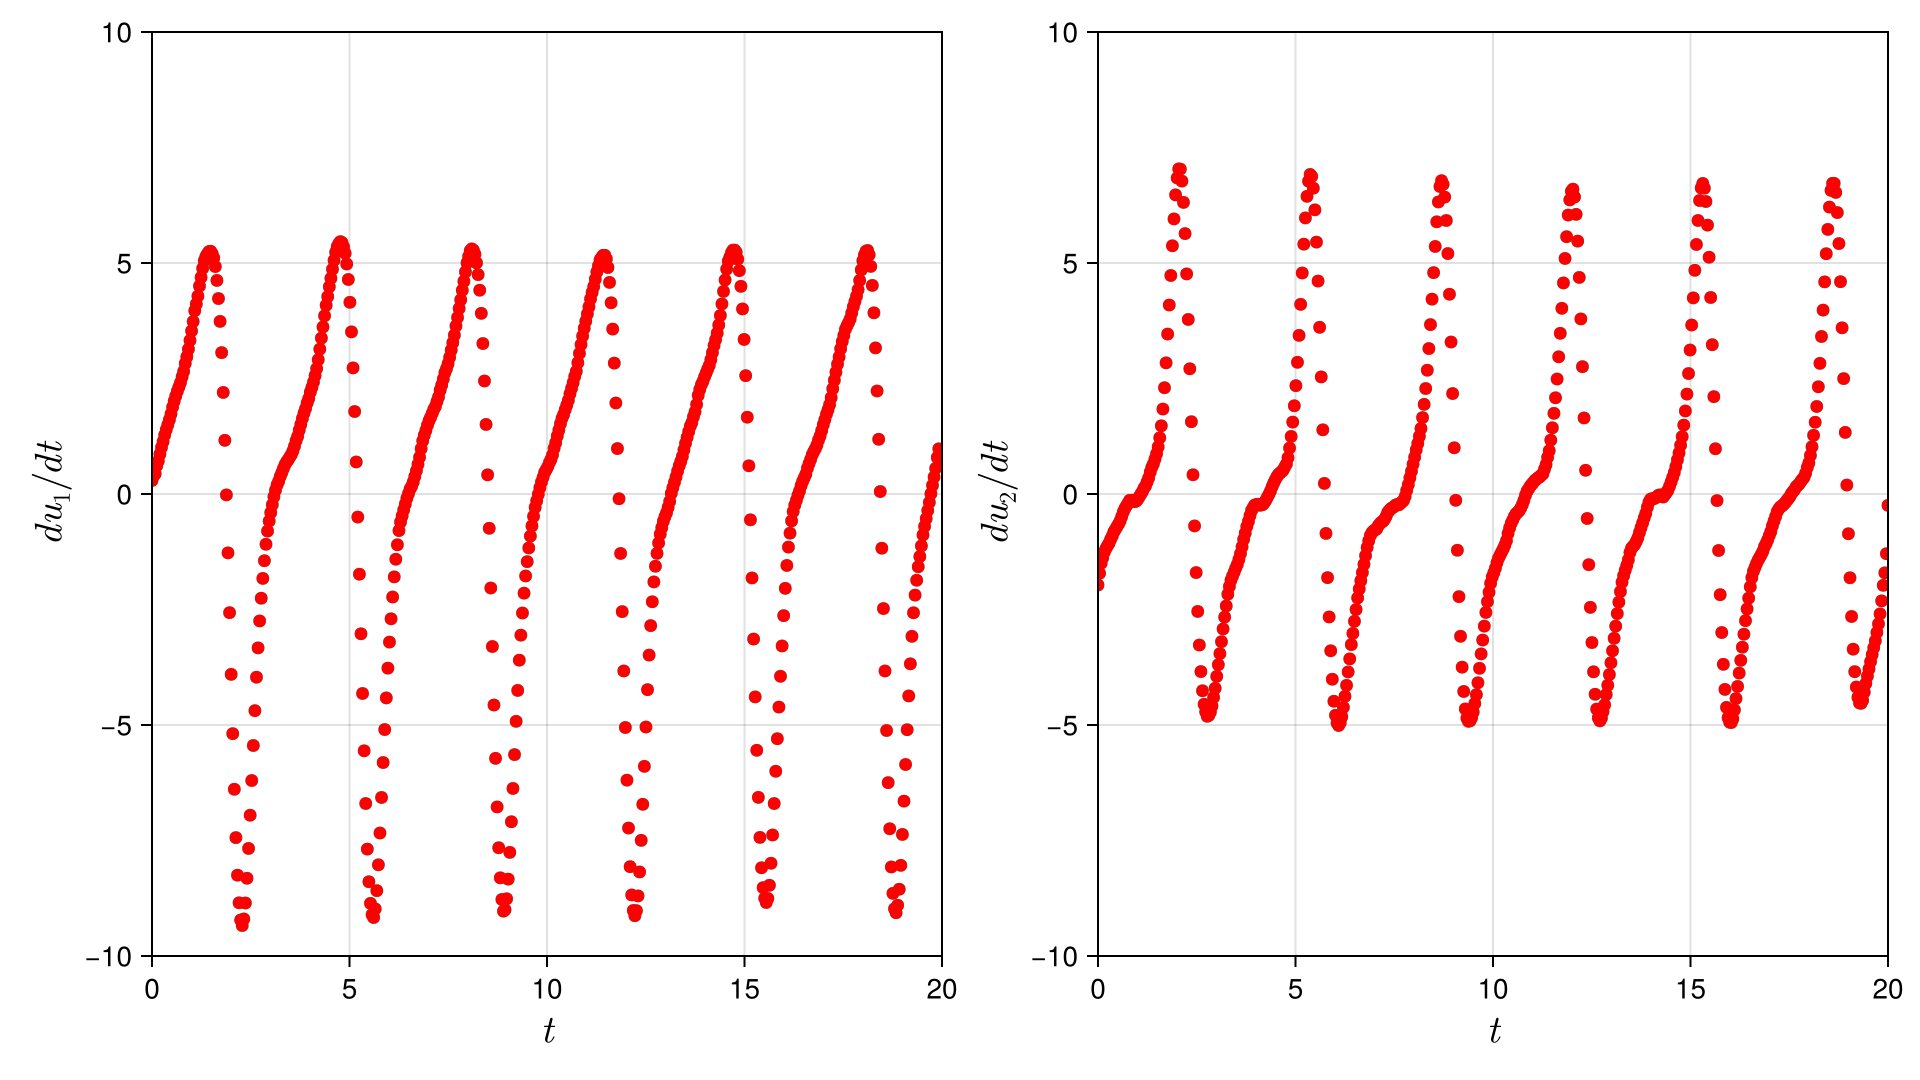

In [16]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)

ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"du_1/dt")
xlims!(ax1,0,tspan[2])
ylims!(ax1,-10,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"du_2/dt")
xlims!(ax2,0,tspan[2])
ylims!(ax2,-10,10)

CairoMakie.scatter!(ax1,tsteps, du[1,:];color=:red)
CairoMakie.scatter!(ax2,tsteps, du[2,:];color=:red)
fig

Set up architecture of Neural Network

In [18]:
dudtNODEs = Chain(Dense(2, 5, tanh),
            Dense(5, 5, tanh),
             Dense(5, 2))
pinit, st = Lux.setup(rng, dudtNODEs)

((layer_1 = (weight = Float32[-1.1581415 1.5142938; -0.34795535 -1.7613096; … ; 0.82695067 1.206606; 1.1870856 -2.0076346], bias = Float32[-0.0488412, 0.15074722, 0.26350075, -0.5430307, -0.1785027]), layer_2 = (weight = Float32[-0.75986534 0.43074012 … 0.47274795 0.5585953; 1.1247 1.0111138 … -0.91704994 -1.0609369; … ; -0.06368382 0.41536182 … 0.20407575 -0.21100196; 0.85899216 0.4309111 … -0.21291661 -0.20391247], bias = Float32[0.06063714, -0.35909224, 0.24739675, 0.20011091, -0.08521403]), layer_3 = (weight = Float32[-0.46298456 -0.6552769 … -0.64265066 0.2774397; -0.54493195 -0.4168042 … 0.52564657 -0.11589243], bias = Float32[-0.10538543, 0.11463816])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

In [19]:
function loss(p,(du, u))
    cost = zero(first(p))
    for i in 1:size(du, 2)
        _du, _ = dudtNODEs(@view(u[:, i]), p, st)
        dui = @view du[:, i]
        cost += sum(abs2, _du  .- dui)
    end
    return 0.5*cost/size(du, 2)
end

loss (generic function with 1 method)

Collocation training

In [20]:
# Initialize a vector to store loss values
loss_history = Float64[]

callback = function (p, l)
    if p.iter % 100 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((p, x) -> loss(p,(du,u)), adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(pinit),(du,u))
result_neuralode = Optimization.solve(optprob, OptimizationOptimisers.Adam(learning_rate); callback, epochs =max_iter_colloc)


┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [Base.ReshapedArray{Float64, 2, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}, Tuple{}}]). Converting to common type to to attempt to use BLAS. This may be slow.
└ @ LuxLib.Impl /Users/asho/.julia/packages/LuxLib/zPBrt/src/impl/matmul.jl:198


Iteration: 100, Loss: 4.107478151610634
Iteration: 200, Loss: 0.2902036775096754
Iteration: 300, Loss: 0.07846633808390711
Iteration: 400, Loss: 0.04396657576101186
Iteration: 500, Loss: 0.031911313894158556
Iteration: 600, Loss: 0.02682773333324844
Iteration: 700, Loss: 0.024010411438473996
Iteration: 800, Loss: 0.022295482597624493
Iteration: 900, Loss: 0.021129236147817372
Iteration: 1000, Loss: 0.020436820069342384
Iteration: 1100, Loss: 0.01981544242455555
Iteration: 1200, Loss: 0.019840198793450933
Iteration: 1300, Loss: 0.019155179789050947
Iteration: 1400, Loss: 0.01894268531408251
Iteration: 1500, Loss: 0.018790295159705206
Iteration: 1600, Loss: 0.01866147381133072
Iteration: 1700, Loss: 0.01870714753221046
Iteration: 1800, Loss: 0.018479565122306228
Iteration: 1900, Loss: 0.018405156161641636
Iteration: 2000, Loss: 0.018351100570723453
Iteration: 2000, Loss: 0.018351100570723453


retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[-0.34008098 0.5545368; -0.40901965 -0.8407444; … ; 0.40994546 0.43537876; 0.16600291 -0.51304483], bias = Float32[-1.0268598, 1.8197551, 0.75296164, -2.8653164, 0.2673394]), layer_2 = (weight = Float32[-0.54778194 0.6748473 … 1.6779834 0.08365857; 1.2633157 0.483067 … -0.2877402 -1.8647996; … ; -0.25722894 0.09363836 … 1.8783035 -1.3059673; 1.5892823 0.5827118 … 0.547768 -0.5411452], bias = Float32[-0.09849531, 0.23616436, -0.53352374, 0.34919298, 0.93876356]), layer_3 = (weight = Float32[-0.81901145 -2.27931 … -2.823143 -2.0199437; 1.9520406 -0.5196791 … 1.4216695 -2.3430624], bias = Float32[-1.9459854, 1.7119308]))

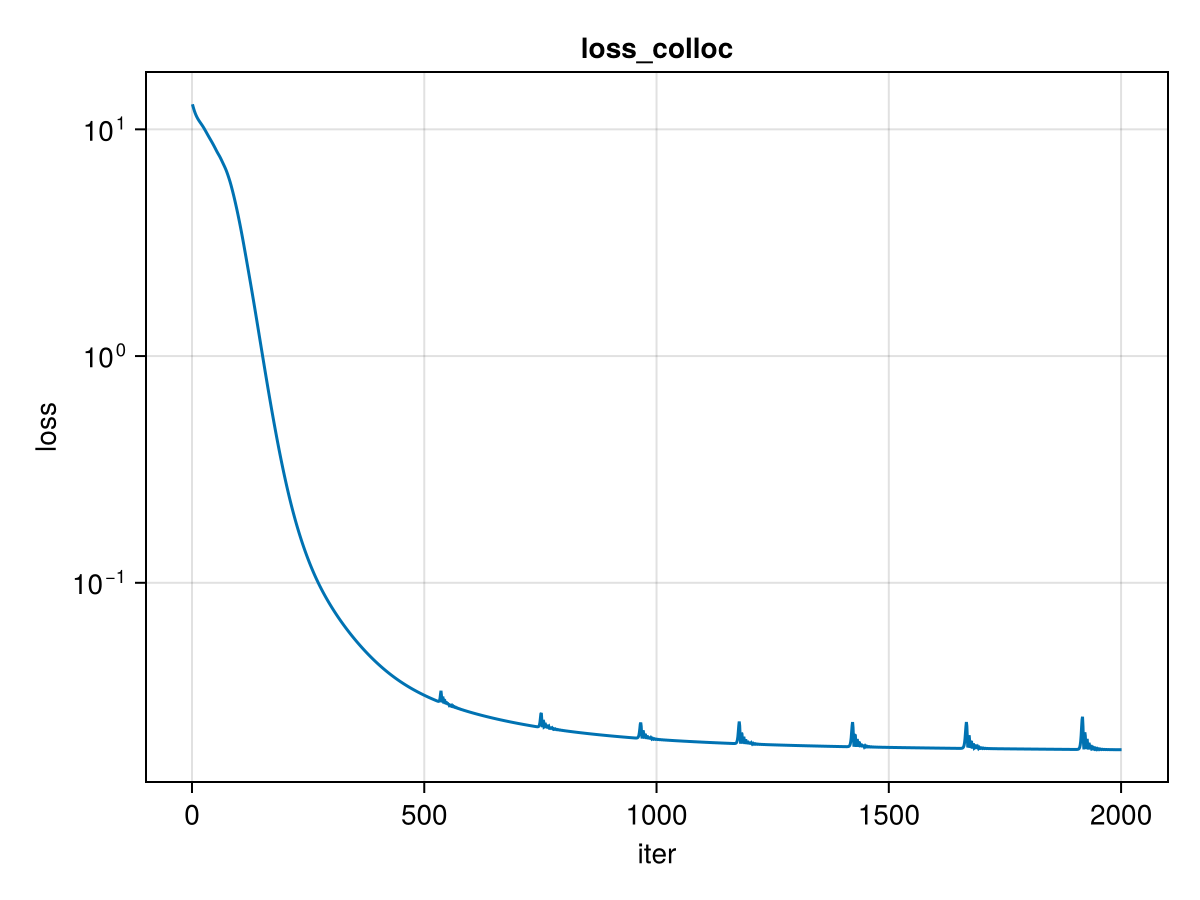

In [21]:
#Plot loss function
#
loss_history_collocation=copy(loss_history)
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel="loss",title="loss_colloc")
CairoMakie.lines!(ax,loss_history_collocation)
save("loss_collocation.png", fig)
fig


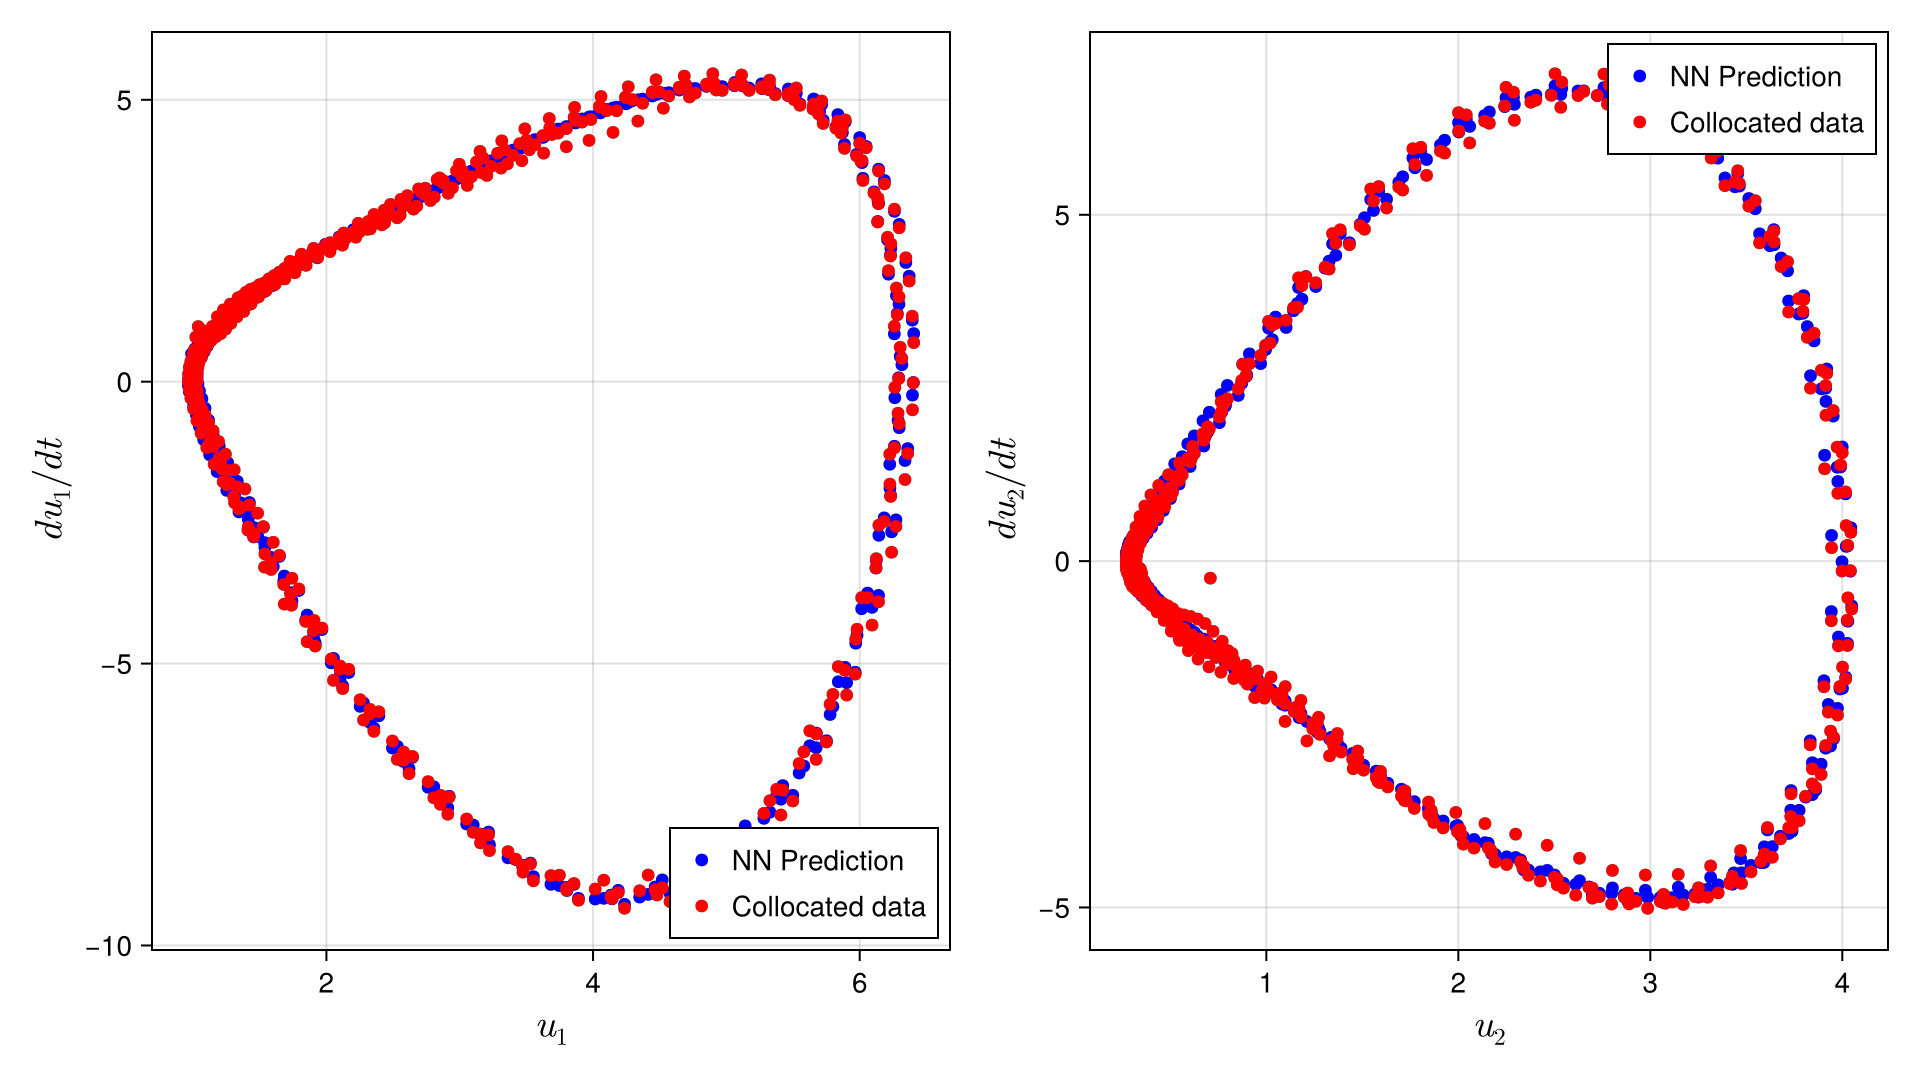

In [ ]:
du_pred,_=dudtNODEs(u, result_neuralode.u, st)
fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"u_1",
    ylabel=L"du_1/dt")
CairoMakie.scatter!(ax1,u[1,:],du_pred[1,:],marker=:circle,color=:blue,label="NN Prediction")
CairoMakie.scatter!(ax1,u[1,:],du[1,:],marker=:circle,color=:red, label="Collocated data")
axislegend(ax1;position=:rb)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"u_2",
    ylabel=L"du_2/dt")
CairoMakie.scatter!(ax2,u[2,:],du_pred[2,:],marker=:circle,color=:blue,label="NN Prediction")
CairoMakie.scatter!(ax2,u[2,:],du[2,:],marker=:circle,color=:red, label="Collocated data")
axislegend(ax2;position=:rt)

#save("result_collocation_training.png", fig)
fig


Predict using model for collocation training and compare with validation data

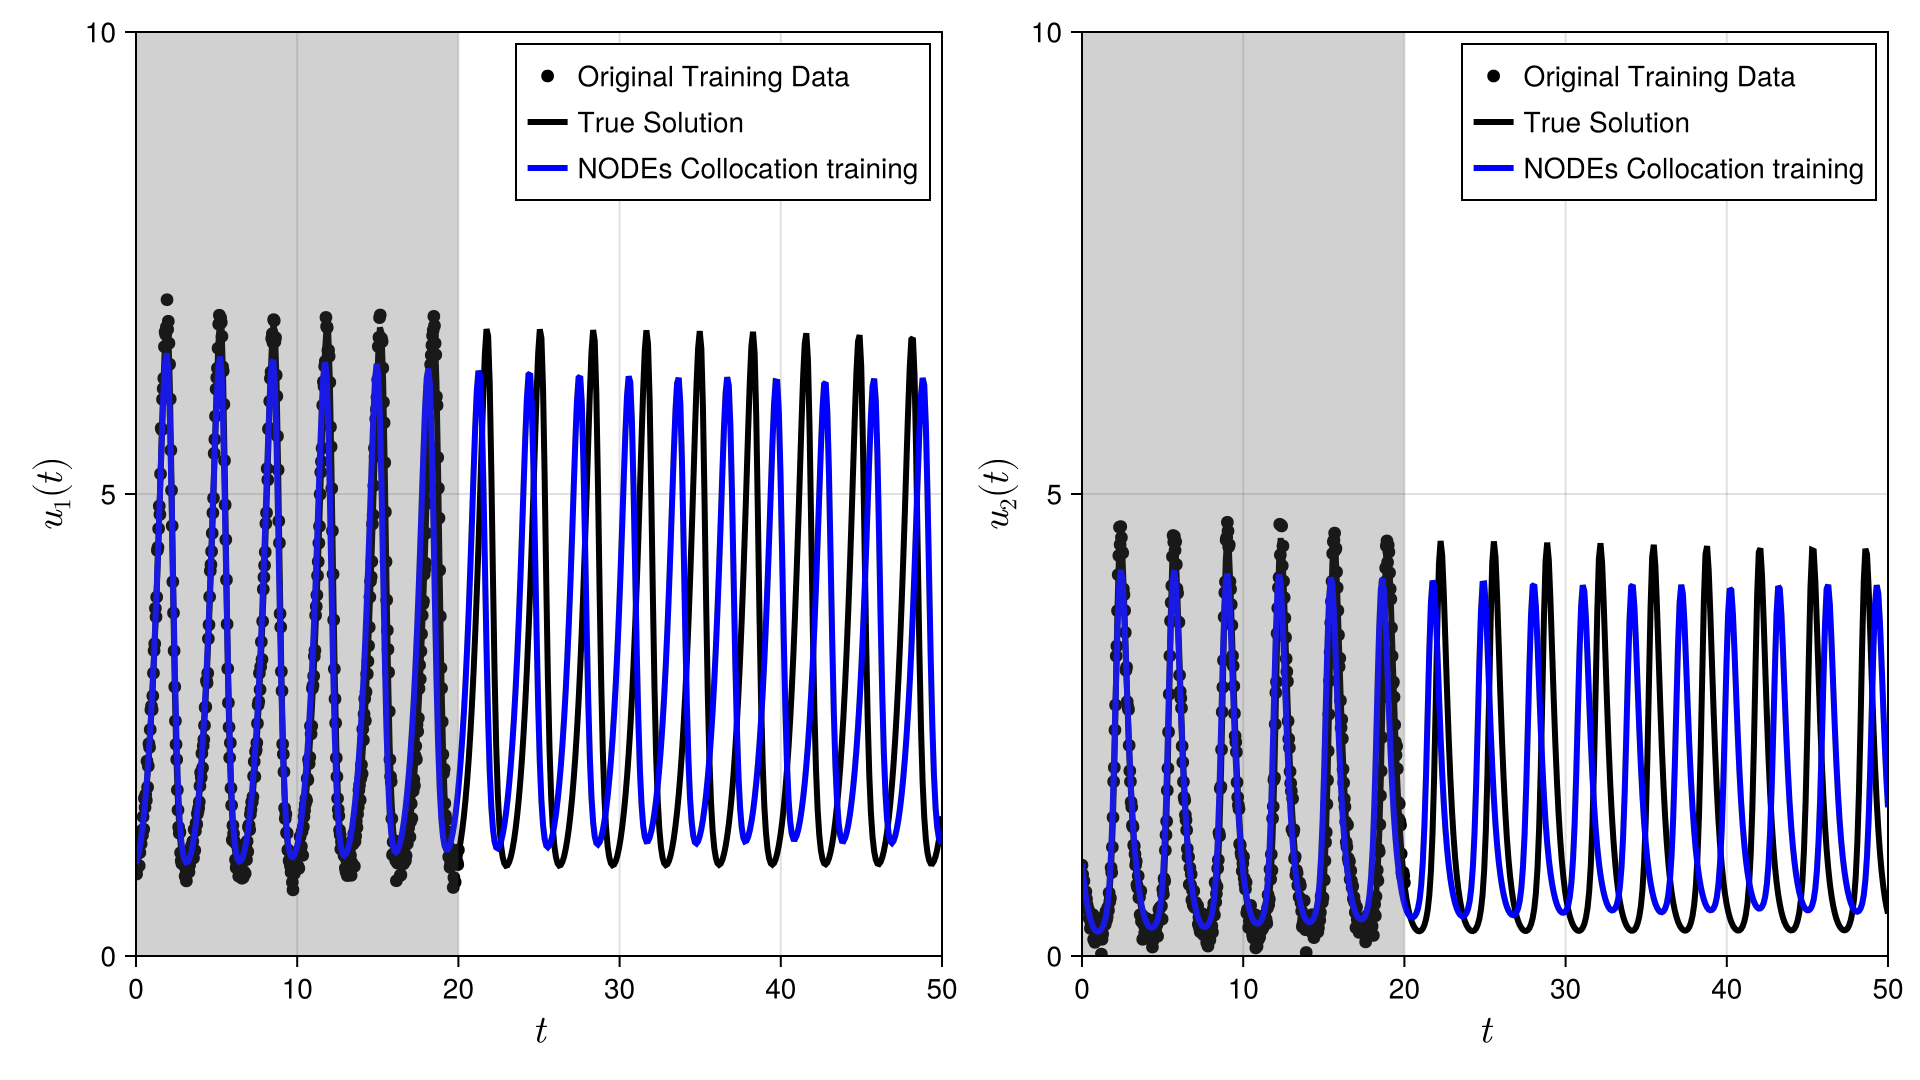

In [24]:
smodel_colloc = StatefulLuxLayer(dudtNODEs, result_neuralode, st)
dudt_colloc(u, p, t) = smodel_colloc(u, p)
prob_colloc = ODEProblem(dudt_colloc, u0, (tspan2[1], tspan2[2]),result_neuralode.u)
nn_sol_colloc = solve(prob_colloc, Tsit5(); sensealg=InterpolatingAdjoint(), saveat=tsteps2)
ComputedSolutionColloc=convert(AbstractArray,nn_sol_colloc)

fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)")

CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax1,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax1,nn_sol_colloc.t,ComputedSolutionColloc[1,:]; linewidth = 3,color=:blue,label="NODEs Collocation training")
CairoMakie.vspan!(ax1,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax1;position=:rt)
xlims!(ax1,tspan2[1],tspan2[2])
ylims!(ax1,0,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax2,tsteps2, data_true[2,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax2,nn_sol_colloc.t,ComputedSolutionColloc[2,:]; linewidth = 3,color=:blue,label="NODEs Collocation training")
CairoMakie.vspan!(ax2,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax2;position=:rt)
xlims!(ax2,tspan2[1],tspan2[2])
ylims!(ax2,0,10)
fig

Now do NODEs training using the adjoint method

In [25]:
smodel = StatefulLuxLayer(dudtNODEs, result_neuralode, st)

function loss_adjoint(θ, (u, t))
    u0 = u[:, 1]
    dudt(u, p, t) = smodel(u, p)
    prob = ODEProblem(dudt, u0, (t[1], t[end]), θ)
    sol = solve(prob, Tsit5();  saveat=t)
    pred = stack(sol.u)

    return MSELoss()(pred, u)
end

loss_history = Float64[]
opt_func = OptimizationFunction(loss_adjoint, Optimization.AutoZygote())
opt_prob = OptimizationProblem(opt_func, result_neuralode.u, (data,tsteps))
numerical_neuralode = Optimization.solve(opt_prob, Optimisers.Adam(learning_rate); callback, epochs = max_iter_NODEs)
loss_history_NODEs=copy(loss_history)


Iteration: 100, Loss: 0.14060003546270863
Iteration: 200, Loss: 0.08593073614090867
Iteration: 300, Loss: 0.1256055394221636
Iteration: 400, Loss: 0.07903965795577259
Iteration: 500, Loss: 0.04160714478542802
Iteration: 600, Loss: 0.05049093658580096
Iteration: 700, Loss: 0.03608470018267043
Iteration: 800, Loss: 0.038102801602666755
Iteration: 900, Loss: 0.035009479261173405
Iteration: 1000, Loss: 0.031140198552359062
Iteration: 1100, Loss: 0.04550482862057953
Iteration: 1200, Loss: 0.07133432160615093
Iteration: 1300, Loss: 0.029125334742162494
Iteration: 1400, Loss: 0.03072015976157519
Iteration: 1500, Loss: 0.023181997798524926
Iteration: 1600, Loss: 0.07804375561731396
Iteration: 1700, Loss: 0.15251756064947386
Iteration: 1800, Loss: 0.049571493154535
Iteration: 1900, Loss: 0.027089815301439068
Iteration: 2000, Loss: 0.04102387568285047
Iteration: 2000, Loss: 0.020846470266529783


2001-element Vector{Float64}:
  1.8574205088801015
 15.230182976166983
 19.862769389631314
 15.624752491180788
 10.522272806093039
  9.142989207057342
  1.0937712381409384
  0.2802913056779984
  3.3756220207548115
  3.471147608218233
  ⋮
  0.041335433697198026
  0.037714386963390474
  0.024976377857255854
  0.027304480435559525
  0.03436888104147931
  0.03828946007563597
  0.02797971361789132
  0.04102387568285047
  0.020846470266529783

Predict using NODEs solution and plot

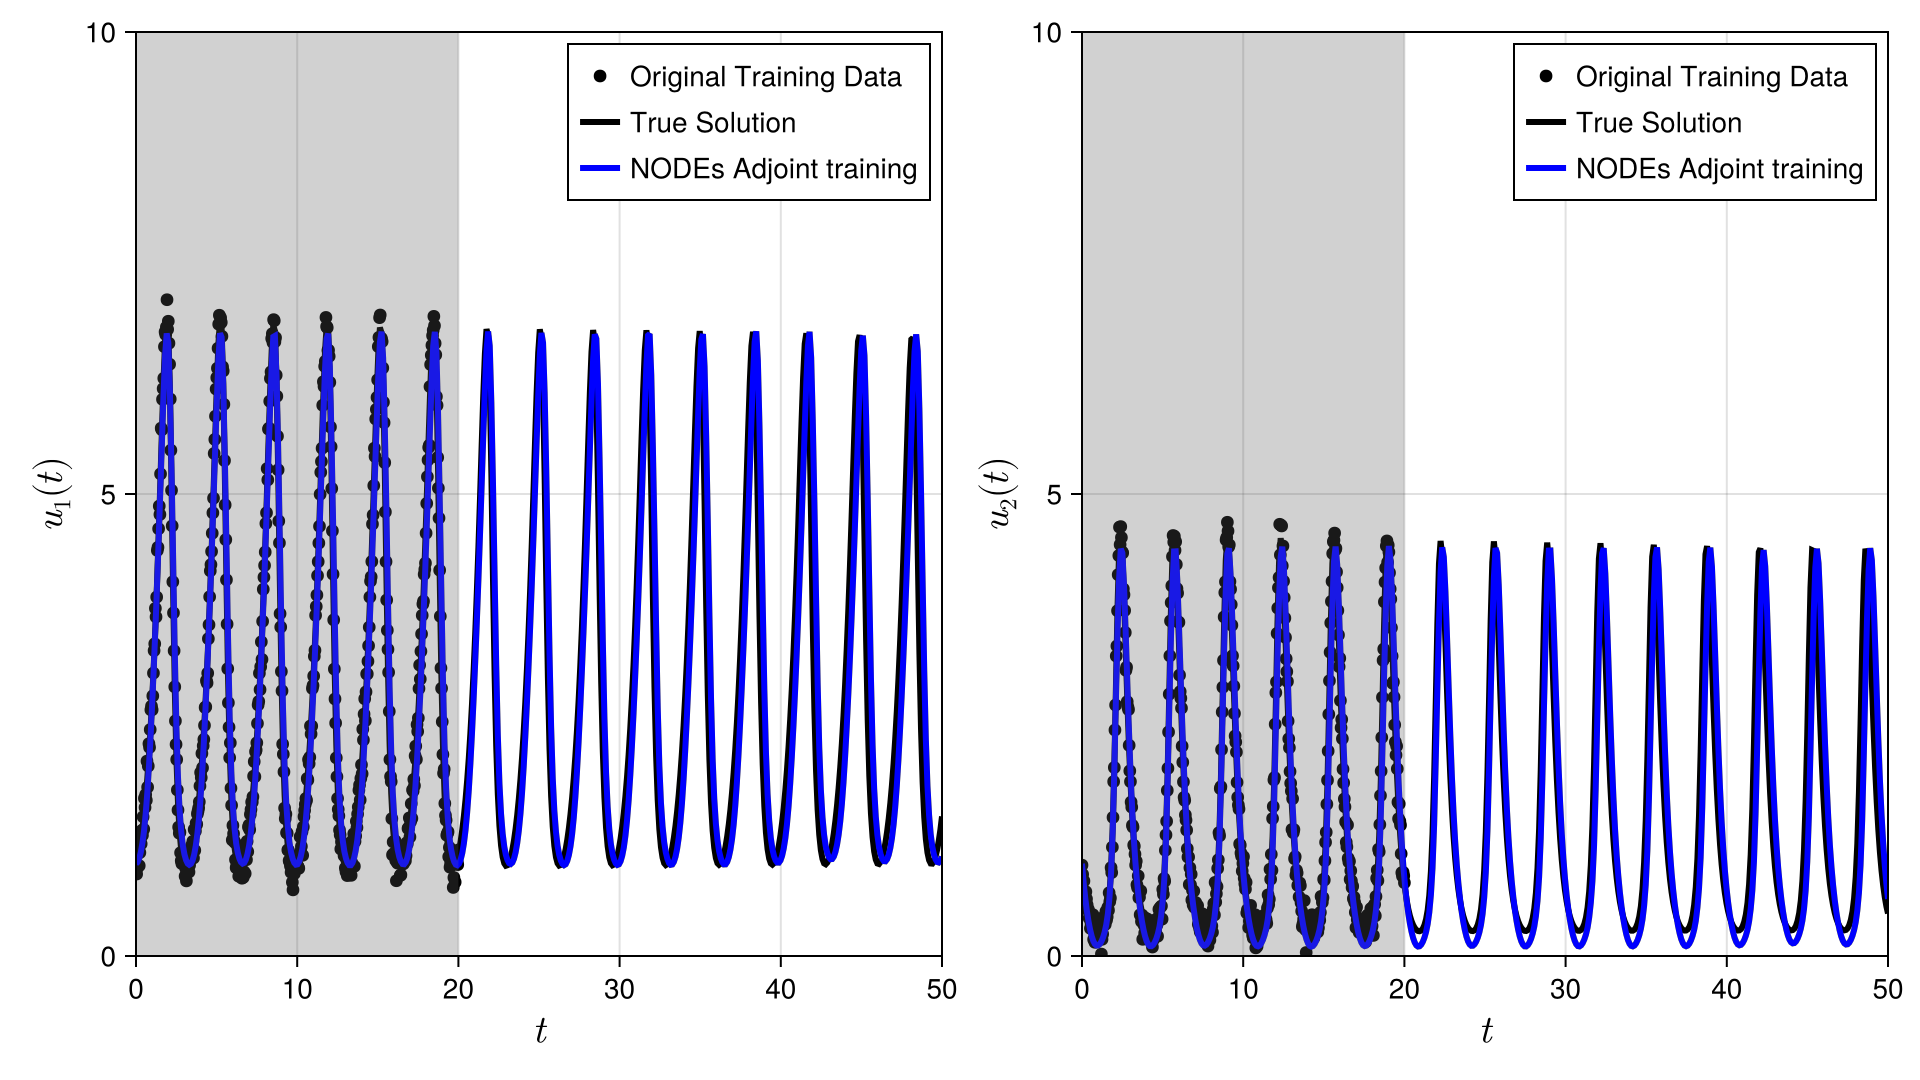

In [26]:
trained_model=StatefulLuxLayer(dudtNODEs, numerical_neuralode.u, smodel.st)
Finaldudt(u, p, tplot) = trained_model(u, p)
prob = ODEProblem(Finaldudt, u0, (tspan2[1],tspan2[2]), numerical_neuralode.u) 
nn_sol = solve(prob, Tsit5(); saveat=tsteps2)


ComputedSolution_nodes=convert(AbstractArray,nn_sol)


fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_1(t)")

CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax1,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax1,nn_sol_colloc.t,ComputedSolution_nodes[1,:]; linewidth = 3,color=:blue,label="NODEs Adjoint training")
CairoMakie.vspan!(ax1,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax1;position=:rt)
xlims!(ax1,tspan2[1],tspan2[2])
ylims!(ax1,0,10)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u_2(t)")
CairoMakie.scatter!(ax2,tsteps, data[2,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax2,tsteps2, data_true[2,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax2,nn_sol_colloc.t,ComputedSolution_nodes[2,:]; linewidth = 3,color=:blue,label="NODEs Adjoint training")
CairoMakie.vspan!(ax2,tspan[1], tspan[2];color=(:grey, 0.2))
axislegend(ax2;position=:rt)
xlims!(ax2,tspan2[1],tspan2[2])
ylims!(ax2,0,10)
fig

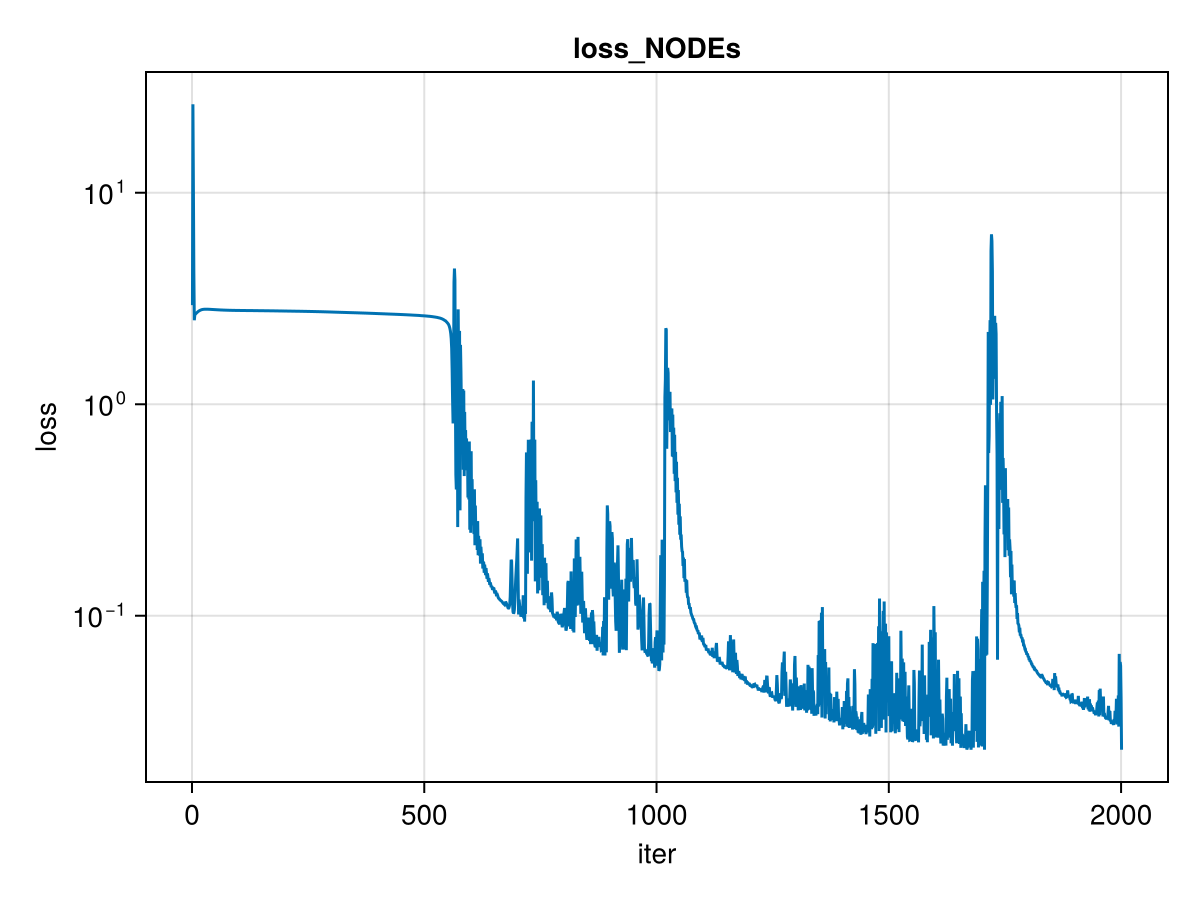

In [19]:
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel="loss",title="loss_NODEs")
CairoMakie.lines!(ax,loss_history_NODEs)
save("loss_NODEs.png", fig)
fig